In [1]:
# Cel (22.08.2026, kontynuacja 20260822a.ipynb): wynik dzisiejszego skanu
# "bez 2006-2009" (patrz 20260822.txt) pokazal duzy spadek sily ekstremum
# (np. athn d=5: -11.94 -> -4.74) po wykluczeniu klastra - argument PRZECIW
# hipotezie "zawsze cos sie znajdzie" (look-elsewhere). ALE nowy zakres
# (2010-2015, ~5.9 roku) jest krotszy niz oryginalny (2005-2015, 11 lat) -
# mial mniej "okazji" na przypadkowe ekstremum, wiec spadek moze CZESCIOWO
# wynikac z samej dlugosci okna, nie (tylko) z braku efektu.
#
# Tani sposob to sprawdzic: uzywamy JUZ POLICZONEGO pelnego skanu z 20.08
# (results/t0_scan_{stacja}_d{d}.csv, 11 lat, 22 stacje) i liczymy, jak
# silny jest TYPOWY ekstremum w dowolnym przesuwanym 5.9-letnim wycinku
# tego zakresu (rolling max po istniejacych danych) - ZERO nowych obliczen
# NMDB/MC, tylko przetworzenie CSV juz na dysku. To da rozklad "jak silny
# ekstremum daje losowe okno tej dlugosci" i pokaze, gdzie na tym tle stoi
# zarowno 2006-2009 (oczekujemy wyraznego maksimum), jak i 2010-2015
# (oczekujemy wartosci typowej/przecietnej, zgodnie z wynikiem z 20260822a).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
STATIONS = ["mosc", "oulu", "athn", "hrms", "sopb"]
D_VALUES = [1, 5]
HOMOLA_LOG10_PPDF_BENCHMARK = -8

full_scans = {}
excl_scans = {}
for name in STATIONS:
    full_scans[name] = {}
    excl_scans[name] = {}
    for d in D_VALUES:
        df_full = pd.read_csv(f"{RESULTS_DIR}/t0_scan_{name}_d{d}.csv", parse_dates=["t0"])
        df_full["neg_log10_PPDF"] = -np.log10(df_full["PPDF"].clip(lower=1e-300))
        full_scans[name][d] = df_full.dropna(subset=["PPDF"]).sort_values("t0")

        df_excl = pd.read_csv(f"{RESULTS_DIR}/t0_scan_excl2009_{name}_d{d}.csv", parse_dates=["t0"])
        df_excl["neg_log10_PPDF"] = -np.log10(df_excl["PPDF"].clip(lower=1e-300))
        excl_scans[name][d] = df_excl.dropna(subset=["PPDF"]).sort_values("t0")

# Dlugosc okna "bez 2006-2009" z dzisiejszego skanu (2020822a.ipynb) -
# wziete wprost z danych, nie na sztywno.
sample_excl = excl_scans["athn"][1]
WINDOW_DAYS = (sample_excl["t0"].max() - sample_excl["t0"].min()).days
print(f"Dlugosc okna do porownania (z 20260822a.ipynb): {WINDOW_DAYS} dni (~{WINDOW_DAYS/365.25:.2f} roku)")


Dlugosc okna do porownania (z 20260822a.ipynb): 2159 dni (~5.91 roku)


In [2]:
# Krzywa "przesuwanego okna": dla kazdego mozliwego startu okna dlugosci
# WINDOW_DAYS wewnatrz PELNEGO 11-letniego zakresu (2005-2015), bierzemy
# NAJSILNIEJSZY (max neg_log10_PPDF) wynik, jaki skan juz znalazl wsrod
# kandydatow t0 nalezacych do tego okna. Krok co 30 dni (wystarczajaco
# gesto, tanio - to tylko filtrowanie/max na juz wczytanych DataFrame'ach).
STEP_DAYS = 30

def sliding_window_max(df, window_days, step_days):
    t0_min, t0_max = df["t0"].min(), df["t0"].max()
    starts = pd.date_range(t0_min, t0_max - pd.Timedelta(days=window_days), freq=f"{step_days}D")
    rows = []
    for start in starts:
        end = start + pd.Timedelta(days=window_days)
        window = df[(df["t0"] >= start) & (df["t0"] < end)]
        if len(window) == 0:
            continue
        best = window.loc[window["neg_log10_PPDF"].idxmax()]
        rows.append(dict(window_start=start, max_neg_log10_PPDF=best["neg_log10_PPDF"], t0_at_max=best["t0"]))
    return pd.DataFrame(rows)

window_curves = {}
for name in STATIONS:
    window_curves[name] = {}
    for d in D_VALUES:
        window_curves[name][d] = sliding_window_max(full_scans[name][d], WINDOW_DAYS, STEP_DAYS)
        print(f"{name} d={d}: {len(window_curves[name][d])} przesuwanych okien policzonych")


mosc d=1: 61 przesuwanych okien policzonych
mosc d=5: 61 przesuwanych okien policzonych
oulu d=1: 61 przesuwanych okien policzonych
oulu d=5: 61 przesuwanych okien policzonych
athn d=1: 61 przesuwanych okien policzonych
athn d=5: 61 przesuwanych okien policzonych
hrms d=1: 61 przesuwanych okien policzonych
hrms d=5: 61 przesuwanych okien policzonych
sopb d=1: 61 przesuwanych okien policzonych
sopb d=5: 61 przesuwanych okien policzonych


In [3]:
# Podsumowanie: gdzie na tle WSZYSTKICH przesuwanych okien (rozklad
# "typowej sily ekstremum dla losowego okna tej dlugosci") stoi (a) okno
# zawierajace klaster 2006-2009 (== okno o najwyzszej wartosci - to samo
# ekstremum, ktore znalazl pelny skan z 20.08), (b) okno 2010-2015 uzyte w
# dzisiejszym skanie "excl2009" (20260822a.ipynb). Percentyl liczony jako
# udzial okien SLABSZYCH niz dane okno - 100% = najsilniejsze ze wszystkich.
EXCL_WINDOW_START = pd.Timestamp("2010-01-01")

rows = []
for name in STATIONS:
    for d in D_VALUES:
        curve = window_curves[name][d]
        if len(curve) == 0:
            continue
        rank_pct = curve["max_neg_log10_PPDF"].rank(pct=True)

        top_idx = curve["max_neg_log10_PPDF"].idxmax()
        top_row = curve.loc[top_idx]

        closest_idx = (curve["window_start"] - EXCL_WINDOW_START).abs().idxmin()
        excl_row = curve.loc[closest_idx]

        rows.append(dict(
            station=name, d=d,
            n_windows=len(curve),
            median_window_max=curve["max_neg_log10_PPDF"].median(),
            top_window_start=top_row["window_start"], top_window_max=top_row["max_neg_log10_PPDF"],
            top_window_percentile=rank_pct.loc[top_idx] * 100,
            excl2009_window_start=excl_row["window_start"], excl2009_window_max=excl_row["max_neg_log10_PPDF"],
            excl2009_window_percentile=rank_pct.loc[closest_idx] * 100,
        ))

calibration_summary = pd.DataFrame(rows).sort_values(["d", "top_window_max"], ascending=[True, False])
pd.set_option("display.width", 160)
print(calibration_summary.to_string(index=False))
print(f"\nBenchmark Homoli: -log10(PPDF) > {-HOMOLA_LOG10_PPDF_BENCHMARK}")
calibration_summary.to_csv("../results/t0_scan_windowed_max_calibration_summary.csv", index=False)


station  d  n_windows  median_window_max    top_window_start  top_window_max  top_window_percentile excl2009_window_start  excl2009_window_max  excl2009_window_percentile
   athn  1         61           9.108724 2005-01-01 06:00:00        9.108724              62.295082   2009-12-06 06:00:00             3.788533                    4.098361
   hrms  1         61           7.111530 2005-01-01 06:00:00        7.111530              61.475410   2009-12-06 06:00:00             3.099581                    1.639344
   oulu  1         61           5.790065 2005-01-01 06:00:00        5.790065              63.934426   2009-12-06 06:00:00             3.459711                    5.737705
   mosc  1         61           3.568142 2009-03-11 06:00:00        4.207540              92.622951   2009-12-06 06:00:00             4.207540                   92.622951
   sopb  1         61           2.887959 2005-01-01 06:00:00        3.005196              92.622951   2009-12-06 06:00:00             2.926116   

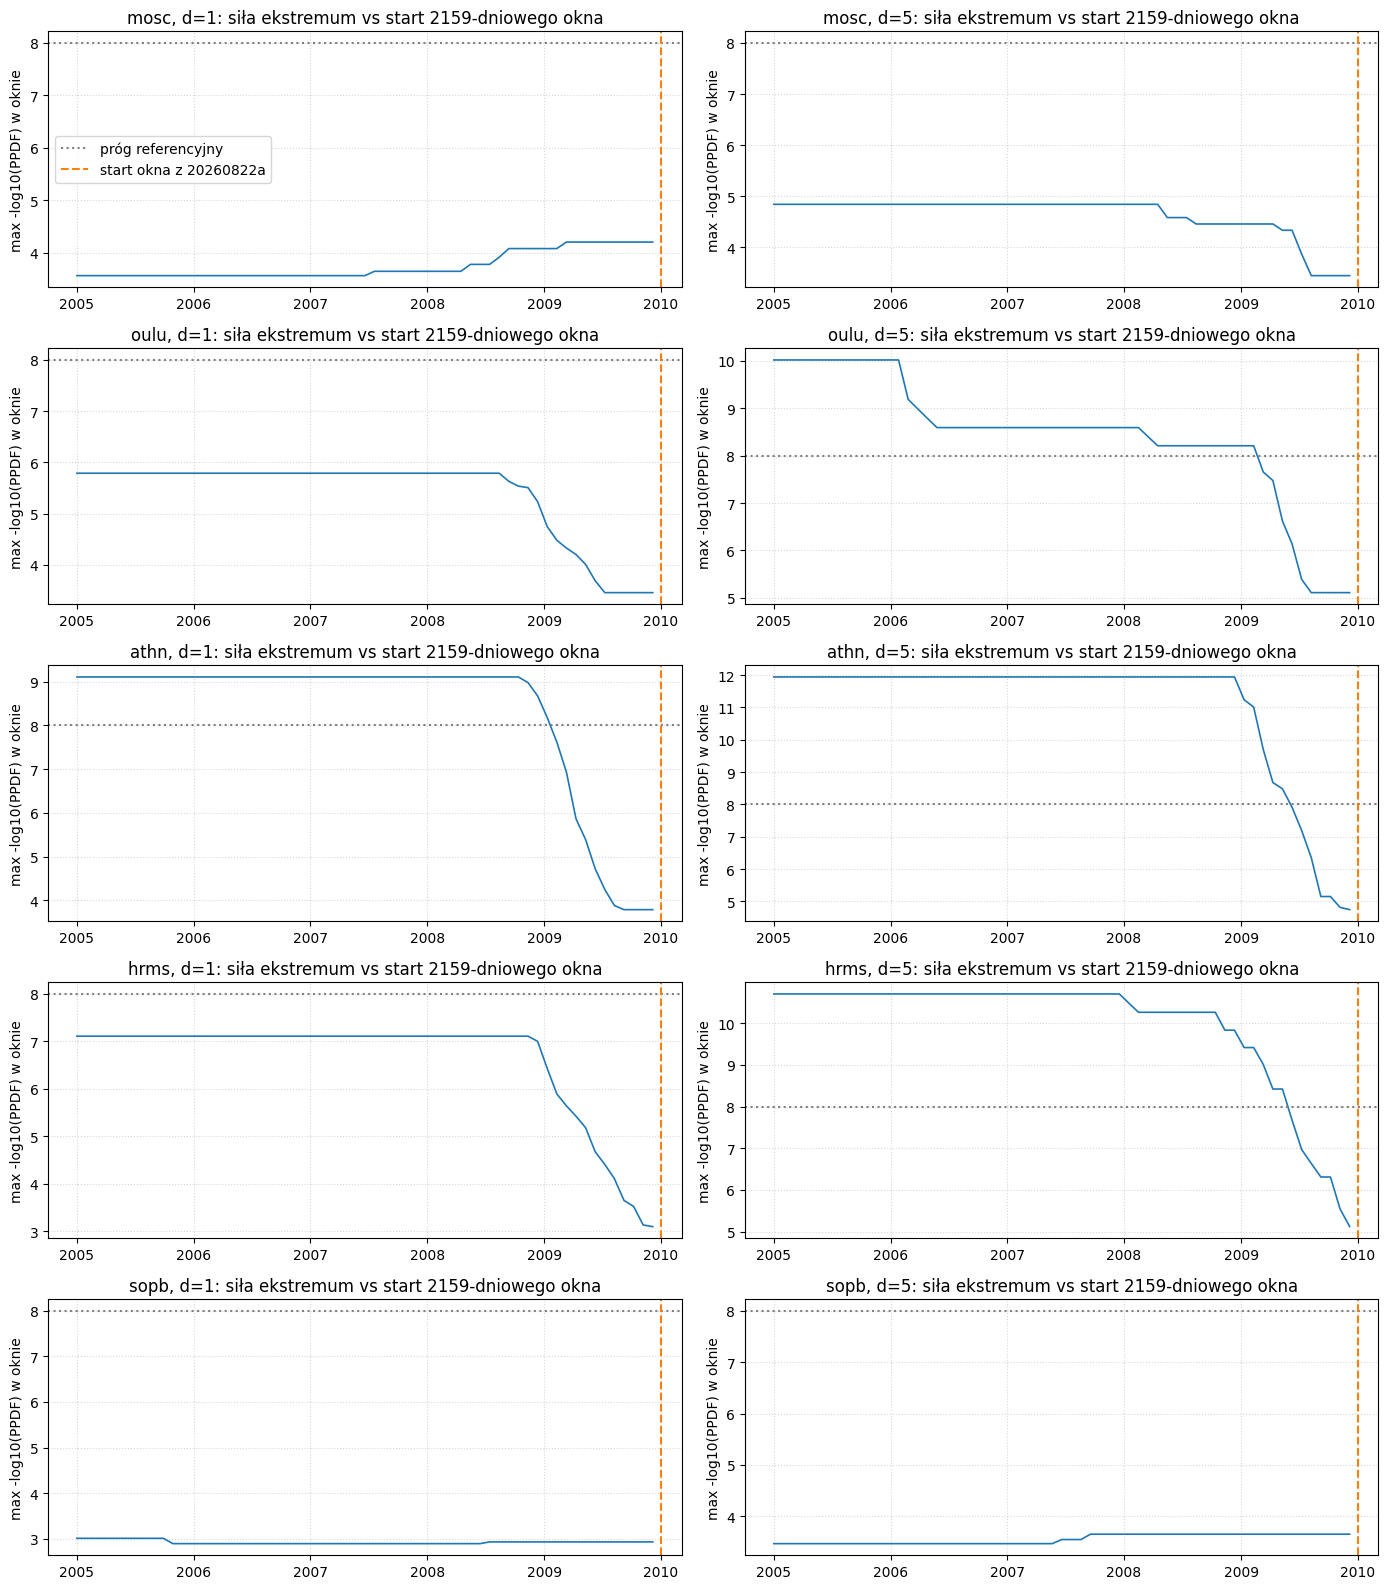

In [4]:
# Wykres: sila ekstremum (max -log10 PPDF) w funkcji POCZATKU przesuwanego
# okna, per stacja/d - pokazuje wprost, czy okno startujace w 2005-2006
# (obejmujace klaster 2006-2009) jest odosobnionym szczytem, czy jednym z
# wielu podobnych. Pionowe linie: poczatek pelnego zakresu (2005, gdzie
# siedzi klaster) i poczatek zakresu z dzisiejszego skanu (2010).
fig, axes = plt.subplots(len(STATIONS), 2, figsize=(14, 3.2 * len(STATIONS)), squeeze=False)
for row_i, name in enumerate(STATIONS):
    for col_i, d in enumerate(D_VALUES):
        ax = axes[row_i][col_i]
        curve = window_curves[name][d]
        ax.plot(curve["window_start"], curve["max_neg_log10_PPDF"], lw=1.2)
        ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", ls=":", label="próg referencyjny")
        ax.axvline(pd.Timestamp("2010-01-01"), color="tab:orange", ls="--", label="start okna z 20260822a")
        ax.set_title(f"{name}, d={d}: siła ekstremum vs start {WINDOW_DAYS}-dniowego okna")
        ax.set_ylabel("max -log10(PPDF) w oknie")
        ax.grid(ls=":", alpha=0.5)
        if row_i == 0 and col_i == 0:
            ax.legend()
fig.tight_layout()
fig.savefig("../results/t0_scan_windowed_max_calibration_plot.png", dpi=120)
plt.show()
